In [2]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import xgboost as xgb

PROJECT_ROOT = Path.cwd().resolve()

while PROJECT_ROOT.name != "Fraud-detection-ML-V2" and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
REPORTS_DIR = PROJECT_ROOT / "outputs" / "reports"

TEST_FEATURE_PATH = PROCESSED_DATA_DIR / "ml_test_features.csv"
FINAL_MODEL_PATH = MODELS_DIR / "xgboost_final_candidate.json"
FINAL_EVALUATION_PATH = METRICS_DIR / "final_model_evaluation.json"

if not TEST_FEATURE_PATH.exists():
    raise FileNotFoundError(
        f"Test feature file not found:\n{TEST_FEATURE_PATH}"
    )

if not FINAL_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Final model candidate not found:\n{FINAL_MODEL_PATH}"
    )

if not FINAL_EVALUATION_PATH.exists():
    raise FileNotFoundError(
        f"Final evaluation file not found:\n{FINAL_EVALUATION_PATH}"
    )

df = pd.read_csv(TEST_FEATURE_PATH)

ML_FEATURES = [
    "amount",
    "amount_vs_avg_ratio",
    "txn_count_last_5min",
    "time_since_last_txn_sec",
    "distance_from_last_location_km",
    "merchant_category_is_new_for_user"
]

TARGET_COLUMN = "is_fraud"

missing_columns = [
    column
    for column in ML_FEATURES + [TARGET_COLUMN]
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

with open(FINAL_EVALUATION_PATH, "r") as file:
    final_evaluation = json.load(file)

final_model = xgb.XGBClassifier()
final_model.load_model(FINAL_MODEL_PATH)

X = df[ML_FEATURES].copy()
y = df[TARGET_COLUMN].astype(int).copy()

print("========== PHASE 7 DATA LOADED ==========")
print("Test shape:", df.shape)
print("Final model loaded:", True)
print("Selected model:", final_evaluation["selected_model"])
print("Number of features:", len(ML_FEATURES))
print("=========================================")

========== PHASE 7 DATA LOADED ==========
Test shape: (555719, 9)
Final model loaded: True
Selected model: XGBoost_Baseline
Number of features: 6


In [3]:
if X.isnull().any().any():
    raise ValueError(
        "Missing values found in SHAP input."
    )

X_numeric = X.astype(float)

if not np.isfinite(
    X_numeric.to_numpy()
).all():
    raise ValueError(
        "Non-finite values found in SHAP input."
    )

print("========== SHAP INPUT VALIDATION ==========")
print(
    "Missing values:",
    int(X.isnull().sum().sum())
)

print(
    "All values finite:",
    np.isfinite(
        X_numeric.to_numpy()
    ).all()
)

print(
    "Feature order:",
    X.columns.tolist()
)

print(
    "Feature count:",
    len(X.columns)
)

print("===========================================")

========== SHAP INPUT VALIDATION ==========
Missing values: 0
All values finite: True
Feature order: ['amount', 'amount_vs_avg_ratio', 'txn_count_last_5min', 'time_since_last_txn_sec', 'distance_from_last_location_km', 'merchant_category_is_new_for_user']
Feature count: 6


In [4]:
SHAP_SAMPLE_SIZE = min(
    2000,
    len(X)
)

shap_sample = X.sample(
    n=SHAP_SAMPLE_SIZE,
    random_state=42
)

shap_sample = shap_sample[
    ML_FEATURES
].copy()

print("========== SHAP SAMPLE ==========")
print(
    "Sample size:",
    len(shap_sample)
)

print(
    "Feature count:",
    shap_sample.shape[1]
)

print("=================================")

========== SHAP SAMPLE ==========
Sample size: 2000
Feature count: 6


In [5]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "shap"
])

print("SHAP installation completed successfully.")

SHAP installation completed successfully.


In [6]:
import shap

explainer = shap.TreeExplainer(
    final_model
)

print("========== SHAP EXPLAINER ==========")
print(
    "SHAP library loaded:",
    True
)

print(
    "TreeExplainer created:",
    True
)

print(
    "Model:",
    "XGBoost"
)

print("====================================")

========== SHAP EXPLAINER ==========
SHAP library loaded: True
TreeExplainer created: True
Model: XGBoost


In [7]:
shap_values = explainer.shap_values(
    shap_sample
)

shap_values = np.asarray(
    shap_values
)

if shap_values.ndim != 2:
    raise ValueError(
        f"Unexpected SHAP shape: {shap_values.shape}"
    )

if shap_values.shape[1] != len(ML_FEATURES):
    raise ValueError(
        "SHAP feature count does not match model feature count."
    )

print("========== SHAP VALUES ==========")
print(
    "SHAP matrix shape:",
    shap_values.shape
)

print(
    "Expected rows:",
    len(shap_sample)
)

print(
    "Expected features:",
    len(ML_FEATURES)
)

print(
    "SHAP values finite:",
    np.isfinite(shap_values).all()
)

print("=================================")

========== SHAP VALUES ==========
SHAP matrix shape: (2000, 6)
Expected rows: 2000
Expected features: 6
SHAP values finite: True


In [8]:
mean_absolute_shap = (
    np.abs(shap_values)
    .mean(axis=0)
)

shap_importance = pd.DataFrame({
    "feature": ML_FEATURES,
    "mean_absolute_shap": mean_absolute_shap
})

shap_importance = (
    shap_importance
    .sort_values(
        "mean_absolute_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

print("========== GLOBAL SHAP IMPORTANCE ==========")
print(
    shap_importance.to_string(
        index=False
    )
)

print("============================================")

========== GLOBAL SHAP IMPORTANCE ==========
                          feature  mean_absolute_shap
                           amount            3.533193
          time_since_last_txn_sec            0.588931
              amount_vs_avg_ratio            0.529716
   distance_from_last_location_km            0.200379
merchant_category_is_new_for_user            0.022851
              txn_count_last_5min            0.000000


In [9]:
SHAP_IMPORTANCE_PATH = (
    METRICS_DIR
    / "shap_feature_importance.json"
)

shap_importance_records = (
    shap_importance
    .to_dict(orient="records")
)

with open(
    SHAP_IMPORTANCE_PATH,
    "w"
) as file:
    json.dump(
        shap_importance_records,
        file,
        indent=4
    )

print("========== SHAP IMPORTANCE SAVED ==========")
print(
    "File:",
    SHAP_IMPORTANCE_PATH
)

print(
    "File exists:",
    SHAP_IMPORTANCE_PATH.exists()
)

print("===========================================")

========== SHAP IMPORTANCE SAVED ==========
File: C:\Users\Lenovo\Desktop\Fraud-detection-ML-V2\outputs\metrics\shap_feature_importance.json
File exists: True


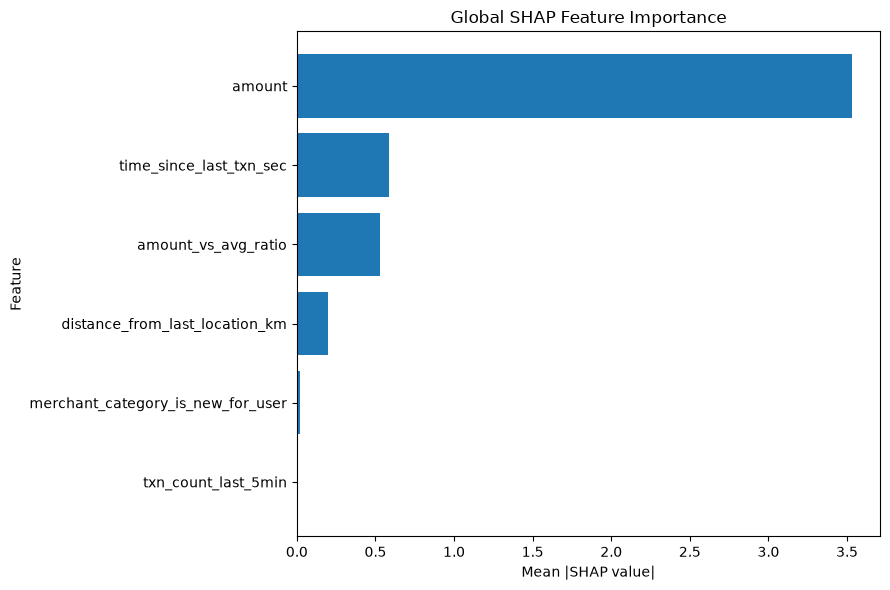

In [10]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(9, 6)
)

plt.barh(
    shap_importance["feature"][::-1],
    shap_importance["mean_absolute_shap"][::-1]
)

plt.xlabel(
    "Mean |SHAP value|"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Global SHAP Feature Importance"
)

plt.tight_layout()

SHAP_BAR_PATH = (
    FIGURES_DIR
    / "shap_feature_importance.png"
)

plt.savefig(
    SHAP_BAR_PATH,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

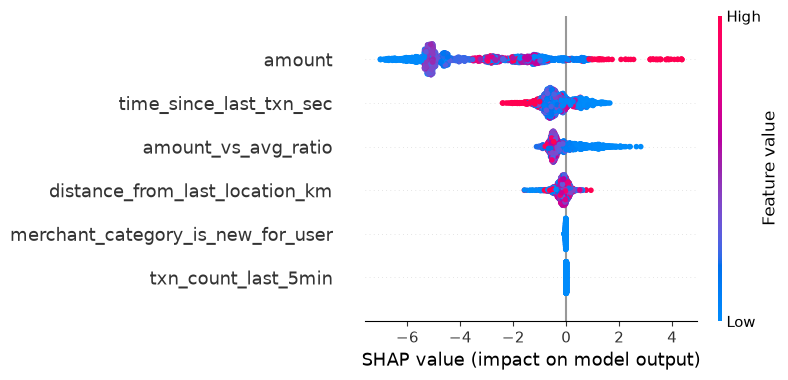

In [11]:
shap.summary_plot(
    shap_values,
    shap_sample,
    show=False
)

plt.tight_layout()

SHAP_SUMMARY_PATH = (
    FIGURES_DIR
    / "shap_summary_plot.png"
)

plt.savefig(
    SHAP_SUMMARY_PATH,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [12]:
sample_probability = (
    final_model
    .predict_proba(
        shap_sample
    )[:, 1]
)

sample_prediction = (
    sample_probability >= 0.5
).astype(int)

print("========== SHAP PREDICTIONS ==========")
print(
    "Predictions generated:",
    len(sample_prediction)
)

print(
    "Fraud predictions:",
    int(
        (sample_prediction == 1).sum()
    )
)

print(
    "Legitimate predictions:",
    int(
        (sample_prediction == 0).sum()
    )
)

print(
    "Probability range:",
    float(sample_probability.min()),
    "to",
    float(sample_probability.max())
)

print("=======================================")

========== SHAP PREDICTIONS ==========
Predictions generated: 2000
Fraud predictions: 141
Legitimate predictions: 1859
Probability range: 0.00032848090631887317 to 0.9968817234039307


In [13]:
highest_risk_index = int(
    np.argmax(
        sample_probability
    )
)

highest_risk_transaction = (
    shap_sample
    .iloc[highest_risk_index]
)

highest_risk_shap = (
    shap_values[
        highest_risk_index
    ]
)

highest_risk_score = float(
    sample_probability[
        highest_risk_index
    ]
)

highest_risk_prediction = int(
    sample_prediction[
        highest_risk_index
    ]
)

print("========== HIGHEST RISK TRANSACTION ==========")
print(
    "ML score:",
    highest_risk_score
)

print(
    "Prediction:",
    highest_risk_prediction
)

print()
print(
    highest_risk_transaction
)

print("===============================================")

========== HIGHEST RISK TRANSACTION ==========
ML score: 0.9968817234039307
Prediction: 1

amount                               809.110000
amount_vs_avg_ratio                   13.956322
txn_count_last_5min                    0.000000
time_since_last_txn_sec              356.000000
distance_from_last_location_km       149.295547
merchant_category_is_new_for_user      0.000000
Name: 238148, dtype: float64


In [14]:
feature_explanations = pd.DataFrame({
    "feature": ML_FEATURES,
    "feature_value": (
        highest_risk_transaction
        .to_numpy()
    ),
    "shap_value": highest_risk_shap
})

feature_explanations["absolute_shap"] = (
    feature_explanations["shap_value"]
    .abs()
)

feature_explanations = (
    feature_explanations
    .sort_values(
        "absolute_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

top_shap_features = (
    feature_explanations
    .head(3)
)

print("========== TOP SHAP CONTRIBUTORS ==========")
print(
    top_shap_features.to_string(
        index=False
    )
)

print("============================================")

========== TOP SHAP CONTRIBUTORS ==========
                feature  feature_value  shap_value  absolute_shap
                 amount     809.110000    4.328540       4.328540
time_since_last_txn_sec     356.000000    1.102871       1.102871
    amount_vs_avg_ratio      13.956322    0.247563       0.247563


In [15]:
def format_feature_reason(
    feature,
    value,
    shap_value
):
    direction = (
        "increased"
        if shap_value > 0
        else "decreased"
    )

    if feature == "amount":
        description = (
            f"amount={value:.2f}"
        )

    elif feature == "amount_vs_avg_ratio":
        description = (
            f"amount_vs_avg_ratio={value:.2f}"
        )

    elif feature == "txn_count_last_5min":
        description = (
            f"txn_count_last_5min={value:.0f}"
        )

    elif feature == "time_since_last_txn_sec":
        description = (
            f"time_since_last_txn_sec={value:.2f}"
        )

    elif feature == "distance_from_last_location_km":
        description = (
            f"distance_from_last_location_km={value:.2f}"
        )

    elif feature == "merchant_category_is_new_for_user":
        description = (
            f"merchant_category_is_new_for_user={int(value)}"
        )

    else:
        description = (
            f"{feature}={value}"
        )

    return (
        f"{description} {direction} fraud risk"
    )


reason_parts = []

for _, row in top_shap_features.iterrows():
    reason_parts.append(
        format_feature_reason(
            row["feature"],
            row["feature_value"],
            row["shap_value"]
        )
    )

human_readable_reason = (
    "ML explanation: "
    + "; ".join(reason_parts)
    + "."
)

print("========== HUMAN-READABLE ML REASON ==========")
print(human_readable_reason)
print("===============================================")

========== HUMAN-READABLE ML REASON ==========
ML explanation: amount=809.11 increased fraud risk; time_since_last_txn_sec=356.00 increased fraud risk; amount_vs_avg_ratio=13.96 increased fraud risk.


In [16]:
SHAP_EXPLANATION_PATH = (
    REPORTS_DIR
    / "sample_shap_explanation.json"
)

explanation_data = {
    "ml_fraud_score": highest_risk_score,
    "ml_prediction": highest_risk_prediction,
    "top_features": (
        top_shap_features[
            [
                "feature",
                "feature_value",
                "shap_value"
            ]
        ]
        .to_dict(
            orient="records"
        )
    ),
    "human_readable_reason": human_readable_reason
}

with open(
    SHAP_EXPLANATION_PATH,
    "w"
) as file:
    json.dump(
        explanation_data,
        file,
        indent=4
    )

print("========== SHAP EXPLANATION SAVED ==========")
print(
    "File:",
    SHAP_EXPLANATION_PATH
)

print(
    "File exists:",
    SHAP_EXPLANATION_PATH.exists()
)

print("============================================")

========== SHAP EXPLANATION SAVED ==========
File: C:\Users\Lenovo\Desktop\Fraud-detection-ML-V2\outputs\reports\sample_shap_explanation.json
File exists: True


In [17]:
shap_validation = {
    "explainer_created": True,
    "correct_feature_count": (
        shap_values.shape[1]
        == len(ML_FEATURES)
    ),
    "correct_sample_count": (
        shap_values.shape[0]
        == len(shap_sample)
    ),
    "all_shap_values_finite": (
        np.isfinite(shap_values).all()
    ),
    "importance_file_saved": (
        SHAP_IMPORTANCE_PATH.exists()
    ),
    "bar_plot_saved": (
        SHAP_BAR_PATH.exists()
    ),
    "summary_plot_saved": (
        SHAP_SUMMARY_PATH.exists()
    ),
    "sample_explanation_saved": (
        SHAP_EXPLANATION_PATH.exists()
    ),
    "human_reason_generated": (
        isinstance(
            human_readable_reason,
            str
        )
        and len(
            human_readable_reason.strip()
        ) > 0
    )
}

print("========== SHAP VALIDATION ==========")

for name, value in shap_validation.items():
    print(
        f"{name}:",
        value
    )

print()

print(
    "Overall SHAP validation:",
    all(
        shap_validation.values()
    )
)

print("=====================================")

========== SHAP VALIDATION ==========
explainer_created: True
correct_feature_count: True
correct_sample_count: True
all_shap_values_finite: True
importance_file_saved: True
bar_plot_saved: True
summary_plot_saved: True
sample_explanation_saved: True
human_reason_generated: True

Overall SHAP validation: True


In [18]:
print()
print("================================================")
print("     STREAMSENTINEL V2 — PHASE 7 SUMMARY")
print("================================================")

print()

print(
    "Final model:",
    final_evaluation["selected_model"]
)

print(
    "SHAP sample size:",
    len(shap_sample)
)

print(
    "Number of ML features:",
    len(ML_FEATURES)
)

print()

print("Top SHAP Features")
print("-----------------")
print(
    shap_importance.head(6).to_string(
        index=False
    )
)

print()

print(
    "SHAP importance saved:",
    SHAP_IMPORTANCE_PATH.exists()
)

print(
    "SHAP bar plot saved:",
    SHAP_BAR_PATH.exists()
)

print(
    "SHAP summary plot saved:",
    SHAP_SUMMARY_PATH.exists()
)

print(
    "Sample explanation saved:",
    SHAP_EXPLANATION_PATH.exists()
)

print(
    "Human-readable reason generated:",
    len(
        human_readable_reason.strip()
    ) > 0
)

print(
    "Overall SHAP validation:",
    all(
        shap_validation.values()
    )
)

print()
print("PHASE 7 SHAP EXPLAINABILITY: COMPLETE")
print("================================================")


     STREAMSENTINEL V2 — PHASE 7 SUMMARY

Final model: XGBoost_Baseline
SHAP sample size: 2000
Number of ML features: 6

Top SHAP Features
-----------------
                          feature  mean_absolute_shap
                           amount            3.533193
          time_since_last_txn_sec            0.588931
              amount_vs_avg_ratio            0.529716
   distance_from_last_location_km            0.200379
merchant_category_is_new_for_user            0.022851
              txn_count_last_5min            0.000000

SHAP importance saved: True
SHAP bar plot saved: True
SHAP summary plot saved: True
Sample explanation saved: True
Human-readable reason generated: True
Overall SHAP validation: True

PHASE 7 SHAP EXPLAINABILITY: COMPLETE
